# CGSS 2017–2023 Judicial Trust Analysis

This notebook consolidates the data-pooling and visualization workflows from `cgss_python` into one file that can be run from top to bottom.

It covers:

1. pooling the cleaned CGSS 2017 and CGSS 2023 datasets;
2. subjective household economic status and judicial trust;
3. birth cohort and judicial trust;
4. a province-level judicial-trust scatter plot; and
5. internet-use frequency and M2-adjusted judicial-trust probability.

Use a Python environment with `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scipy`. The notebook does not overwrite the existing production outputs. It writes its results to `outputs/notebook` and `../figures/notebook`.


## 1. Environment and paths


In [1]:
from pathlib import Path

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from scipy.stats import t as student_t
import seaborn as sns
from IPython.display import Image, display


def locate_cgss_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "code" / "cgss_python",
        Path.cwd().parent / "code" / "cgss_python",
    ]
    required = Path("outputs") / "CGSS2017_cleaned_reference.csv"
    for candidate in candidates:
        if (candidate / required).exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate cgss_python/outputs. Run the notebook from the project directory or the notebook directory.")


CGSS_DIR = locate_cgss_dir()
DATA_DIR = CGSS_DIR / "outputs"
NOTEBOOK_OUTPUT_DIR = DATA_DIR / "notebook"
NOTEBOOK_FIGURE_DIR = CGSS_DIR.parent / "figures" / "notebook"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Code directory: {CGSS_DIR}")
print(f"Data outputs: {NOTEBOOK_OUTPUT_DIR}")
print(f"Figure outputs: {NOTEBOOK_FIGURE_DIR}")


Code directory: E:\一堆文件\UM\CISC7204\assignment01\code\cgss_python
Data outputs: E:\一堆文件\UM\CISC7204\assignment01\code\cgss_python\outputs\notebook
Figure outputs: E:\一堆文件\UM\CISC7204\assignment01\code\figures\notebook


## 2. Pool CGSS 2017 and CGSS 2023

The inputs are two cleaned CSV files. After appending them, the workflow recreates the year-normalized survey weight `wt_n`, within-year income quintile `incq`, and clustering variable `s42c`. It then validates the result against the existing pooled dataset.


In [2]:
EXPECTED_REFERENCE_DIFFERENCES = {
    "trust_bin": "Python preserves missing trust responses instead of recoding them as 0.",
    "trust_c5": "Python preserves missing trust responses instead of recoding them as 0.",
    "trust_c7": "Python preserves missing trust responses instead of recoding them as 0.",
    "internet": "Invalid negative internet-use codes are missing in the Python data.",
    "know_lawyer": "Telephone/inapplicable responses are missing instead of being coded no.",
    "know_police": "Telephone/inapplicable responses are missing instead of being coded no.",
}


def require_columns(df: pd.DataFrame, columns: list[str], source: Path) -> None:
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise KeyError(f"{source} is missing required columns: {missing}")


def build_pooled(data_2017: pd.DataFrame, data_2023: pd.DataFrame) -> pd.DataFrame:
    """Append the two years and create wt_n, incq, and s42c."""
    require_columns(data_2017, BASE_OUTPUT_COLUMNS, Path("2017 input"))
    require_columns(data_2023, BASE_OUTPUT_COLUMNS, Path("2023 input"))

    first = data_2017[BASE_OUTPUT_COLUMNS].copy()
    second = data_2023[BASE_OUTPUT_COLUMNS].copy()
    pooled = pd.concat([first, second], ignore_index=True)

    pooled["year"] = pd.to_numeric(pooled["year"], errors="raise").astype("int64")
    observed_years = set(pooled["year"].unique())
    if observed_years != {2017, 2023}:
        raise ValueError(f"Expected years 2017 and 2023, found {sorted(observed_years)}")

    if pooled.duplicated(["year", "id"]).any():
        duplicate_count = int(pooled.duplicated(["year", "id"]).sum())
        raise ValueError(f"Found {duplicate_count} duplicate year-id records.")

    year_n = pooled.groupby("year")["id"].transform("size")
    year_weight_sum = pooled.groupby("year")["wt"].transform("sum")
    if pooled["wt"].isna().any() or (year_weight_sum <= 0).any():
        raise ValueError("Weights must be present and have a positive sum within each year.")
    pooled["wt_n"] = pooled["wt"] * year_n / year_weight_sum

    pooled["incq"] = 0.0
    for _, indexes in pooled.groupby("year").groups.items():
        valid_indexes = pooled.loc[indexes].index[pooled.loc[indexes, "lninc"].notna()]
        pooled.loc[valid_indexes, "incq"] = (
            pd.qcut(
                pooled.loc[valid_indexes, "lninc"],
                q=5,
                labels=False,
                duplicates="drop",
            )
            .astype("float64")
            .add(1)
        )

    # Kept equivalent to final_work.do. A separate correction is advisable
    # before clustered regressions because all negative telephone codes coincide.
    pooled["s42c"] = pooled["s42"]
    return pooled[BASE_OUTPUT_COLUMNS + ["wt_n", "incq", "s42c"]]


def summarize(pooled: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for year, group in pooled.groupby("year", sort=True):
        valid = group["trust_bin"].notna() & group["wt_n"].notna()
        weighted_rate = (
            float(np.average(group.loc[valid, "trust_bin"], weights=group.loc[valid, "wt_n"]))
            if valid.any()
            else np.nan
        )
        rows.append(
            {
                "year": int(year),
                "rows": len(group),
                "valid_trust_responses": int(group["trust_bin"].notna().sum()),
                "missing_trust_responses": int(group["trust_bin"].isna().sum()),
                "weighted_trust_rate": weighted_rate,
                "normalized_weight_sum": float(group["wt_n"].sum()),
            }
        )
    return pd.DataFrame(rows)


def validate(pooled: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    """Compare the pooled result with the supplied Stata final dataset."""
    left = pooled.sort_values(["year", "id"]).reset_index(drop=True)
    right = reference.sort_values(["year", "id"]).reset_index(drop=True)
    rows: list[dict[str, object]] = []

    # Stata stores these keys as floats while Python keeps ``year`` as an
    # integer. Compare key values rather than requiring identical dtypes.
    same_keys = len(left) == len(right) and np.array_equal(
        left[["year", "id"]].to_numpy(dtype="float64"),
        right[["year", "id"]].to_numpy(dtype="float64"),
    )
    rows.append(
        {
            "variable": "__rows_and_keys__",
            "python_missing": 0,
            "reference_missing": 0,
            "mismatches": 0 if same_keys else abs(len(left) - len(right)) + 1,
            "status": "PASS" if same_keys else "FAIL",
            "note": "Row count and composite year-id keys",
        }
    )

    for column in [column for column in left.columns if column in right.columns]:
        python_values = left[column]
        reference_values = right[column]
        missing_mismatch = int(
            (python_values.isna() ^ reference_values.isna()).sum()
        )
        both_present = python_values.notna() & reference_values.notna()
        value_mismatch = 0
        if both_present.any():
            value_mismatch = int(
                (~np.isclose(
                    pd.to_numeric(python_values.loc[both_present], errors="coerce"),
                    pd.to_numeric(reference_values.loc[both_present], errors="coerce"),
                    rtol=1e-6,
                    atol=1e-6,
                    equal_nan=True,
                )).sum()
            )
        mismatch_total = missing_mismatch + value_mismatch

        if mismatch_total == 0:
            status = "PASS"
            note = ""
        elif column in EXPECTED_REFERENCE_DIFFERENCES:
            status = "EXPECTED_DIFFERENCE"
            note = EXPECTED_REFERENCE_DIFFERENCES[column]
        else:
            status = "FAIL"
            note = "Unexpected difference requiring review"

        rows.append(
            {
                "variable": column,
                "python_missing": int(python_values.isna().sum()),
                "reference_missing": int(reference_values.isna().sum()),
                "mismatches": mismatch_total,
                "status": status,
                "note": note,
            }
        )
    return pd.DataFrame(rows)


In [3]:
cleaned_2017_path = DATA_DIR / "CGSS2017_cleaned_reference.csv"
cleaned_2023_path = DATA_DIR / "CGSS2023_cleaned_python.csv"
published_pooled_path = DATA_DIR / "CGSS2017_2023_pooled_python.csv"

data_2017 = pd.read_csv(cleaned_2017_path)
data_2023 = pd.read_csv(cleaned_2023_path)
BASE_OUTPUT_COLUMNS = data_2017.columns.tolist()
missing_2023 = set(BASE_OUTPUT_COLUMNS).difference(data_2023.columns)
if missing_2023:
    raise ValueError(f"The cleaned 2023 dataset is missing base columns: {sorted(missing_2023)}")
pooled = build_pooled(data_2017, data_2023)
pooled_summary = summarize(pooled)

pooled_path = NOTEBOOK_OUTPUT_DIR / "CGSS2017_2023_pooled_notebook.csv"
summary_path = NOTEBOOK_OUTPUT_DIR / "pooled_summary_notebook.csv"
validation_path = NOTEBOOK_OUTPUT_DIR / "pooled_validation_notebook.csv"

pooled.to_csv(pooled_path, index=False, encoding="utf-8-sig")
pooled_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

published_pooled = pd.read_csv(published_pooled_path)
validation = validate(pooled, published_pooled)
validation.to_csv(validation_path, index=False, encoding="utf-8-sig")
if validation["status"].eq("FAIL").any():
    failed = validation.loc[validation["status"].eq("FAIL"), "variable"].tolist()
    raise AssertionError(f"Pooled-data validation failed for: {failed}")

print(pooled_summary.to_string(index=False))
print(f"\nPooled dataset: {pooled_path}")
print(f"Validation status: {validation['status'].value_counts().to_dict()}")


 year  rows  valid_trust_responses  missing_trust_responses  weighted_trust_rate  normalized_weight_sum
 2017 12582                   3953                     8629             0.618767                12582.0
 2023 11326                   5583                     5743             0.831274                11326.0

Pooled dataset: E:\一堆文件\UM\CISC7204\assignment01\code\cgss_python\outputs\notebook\CGSS2017_2023_pooled_notebook.csv
Validation status: {'PASS': 35}


## 3. Subjective household economic status and judicial trust

The x-axis retains all five original response categories. The y-axis shows the `wt_n`-weighted judicial-trust rate within each category.


In [4]:
ECON_ORDER = ["Far below average", "Below average", "Average", "Above average", "Far above average"]
ECON_LABELS = dict(enumerate(ECON_ORDER, start=1))
YEAR_COLORS = {2017: "#0072B2", 2023: "#D55E00"}


def configure_chinese_font() -> None:
    """Choose an installed Chinese font while retaining portable fallbacks."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]
    selected = next((name for name in candidates if name in installed), "DejaVu Sans")
    plt.rcParams["font.sans-serif"] = [selected, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


def load_and_prepare(input_path: Path) -> pd.DataFrame:
    """Load person-level data and retain valid focal-variable observations."""
    data = pd.read_csv(input_path)
    required = {"year", "econ_subj", "trust_bin", "wt_n"}
    missing_columns = required.difference(data.columns)
    if missing_columns:
        raise ValueError(f"The input data is missing required variables: {sorted(missing_columns)}")

    analysis = data.dropna(subset=list(required)).copy()
    analysis = analysis.loc[
        analysis["year"].isin([2017, 2023])
        & analysis["econ_subj"].between(1, 5)
        & analysis["trust_bin"].isin([0, 1])
        & analysis["wt_n"].gt(0)
    ].copy()

    analysis["year"] = analysis["year"].astype(int)
    analysis["econ_group"] = pd.Categorical(
        analysis["econ_subj"].astype(int).map(ECON_LABELS),
        categories=ECON_ORDER,
        ordered=True,
    )
    return analysis


def weighted_summary(analysis: pd.DataFrame) -> pd.DataFrame:
    """Calculate weighted trust rates and Kish-effective-sample-size CIs."""
    records: list[dict[str, float | int | str]] = []
    for (year, econ_group), group in analysis.groupby(
        ["year", "econ_group"], observed=True, sort=True
    ):
        weights = group["wt_n"].to_numpy(dtype=float)
        outcome = group["trust_bin"].to_numpy(dtype=float)
        trust_rate = float(np.average(outcome, weights=weights))
        effective_n = float(weights.sum() ** 2 / np.square(weights).sum())
        standard_error = float(
            np.sqrt(trust_rate * (1.0 - trust_rate) / effective_n)
        )
        records.append(
            {
                "year": int(year),
                "econ_group": str(econ_group),
                "n": int(len(group)),
                "weight_sum": float(weights.sum()),
                "effective_n": effective_n,
                "trust_rate": trust_rate,
                "ci_low": max(0.0, trust_rate - 1.96 * standard_error),
                "ci_high": min(1.0, trust_rate + 1.96 * standard_error),
            }
        )

    summary = pd.DataFrame.from_records(records)
    summary["econ_group"] = pd.Categorical(
        summary["econ_group"], categories=ECON_ORDER, ordered=True
    )
    return summary.sort_values(["year", "econ_group"]).reset_index(drop=True)


def draw_figure(summary: pd.DataFrame, output_path: Path, sample_size: int) -> None:
    """Create and save the comparison chart."""
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.92)
    configure_chinese_font()

    figure, axis = plt.subplots(figsize=(12.2, 7.2))
    sns.lineplot(
        data=summary,
        x="econ_group",
        y="trust_rate",
        hue="year",
        style="year",
        markers=True,
        dashes=False,
        palette=YEAR_COLORS,
        linewidth=2.7,
        markersize=10,
        sort=False,
        ax=axis,
    )

    x_positions = np.arange(len(ECON_ORDER))
    label_offsets = {2017: -0.025, 2023: 0.018}
    for year in (2017, 2023):
        year_data = (
            summary.loc[summary["year"].eq(year)]
            .set_index("econ_group")
            .reindex(ECON_ORDER)
        )
        rates = year_data["trust_rate"].to_numpy(dtype=float)
        lower_error = rates - year_data["ci_low"].to_numpy(dtype=float)
        upper_error = year_data["ci_high"].to_numpy(dtype=float) - rates
        axis.errorbar(
            x_positions,
            rates,
            yerr=np.vstack([lower_error, upper_error]),
            fmt="none",
            ecolor=YEAR_COLORS[year],
            elinewidth=1.5,
            capsize=5,
            capthick=1.5,
            alpha=0.9,
            zorder=2,
        )
        for x_position, rate in zip(x_positions, rates, strict=True):
            axis.text(
                x_position,
                rate + label_offsets[year],
                f"{rate:.1%}",
                color=YEAR_COLORS[year],
                ha="center",
                va="center",
                fontsize=11,
                fontweight="semibold",
            )

    figure.suptitle(
        "Subjective Household Economic Status and Judicial Trust",
        fontsize=19,
        fontweight="bold",
        y=0.965,
    )
    axis.set_title(
        "Comparison of CGSS 2017 and CGSS 2023",
        fontsize=12,
        color="#555555",
        pad=14,
    )
    axis.set_xlabel("Subjective household economic status", labelpad=10)
    axis.set_ylabel("Judicial-trust rate", labelpad=10)
    axis.set_ylim(0.25, 1.0)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    axis.grid(axis="x", visible=False)
    axis.grid(axis="y", color="#D9D9D9", linewidth=0.8, alpha=0.8)
    sns.despine(ax=axis, left=False, bottom=False)

    legend = axis.legend(
        title="Survey year", frameon=False, loc="upper left", bbox_to_anchor=(0.01, 0.99)
    )
    legend.get_title().set_fontweight("semibold")

    figure.text(
        0.10,
        0.015,
        (
            f"Note: Points show wt_n-weighted judicial-trust rates; error bars show approximate 95% confidence intervals. "
            f"The Far above average group is small (2017 n=7; 2023 n=19). Valid N={sample_size:,}."
        ),
        ha="left",
        va="bottom",
        fontsize=9.5,
        color="#555555",
    )
    figure.subplots_adjust(left=0.115, right=0.985, bottom=0.18, top=0.84)
    figure.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(figure)


 year        econ_group    n  weight_sum  effective_n  trust_rate   ci_low  ci_high
 2017 Far below average  319  248.785194   203.708182    0.537840 0.469374 0.606306
 2017     Below average 1391 1304.073140   878.114182    0.585370 0.552784 0.617955
 2017           Average 1948 2164.597100  1225.853200    0.640628 0.613767 0.667488
 2017     Above average  267  288.504465   184.571708    0.681178 0.613945 0.748410
 2017 Far above average    7    9.881312     4.560704    0.656918 0.221211 1.000000
 2023 Far below average  440  440.000000   440.000000    0.781818 0.743227 0.820410
 2023     Below average 1927 1927.000000  1927.000000    0.809030 0.791479 0.826580
 2023           Average 2821 2821.000000  2821.000000    0.858561 0.845701 0.871420
 2023     Above average  324  324.000000   324.000000    0.805556 0.762460 0.848651
 2023 Far above average   19   19.000000    19.000000    0.789474 0.606157 0.972790


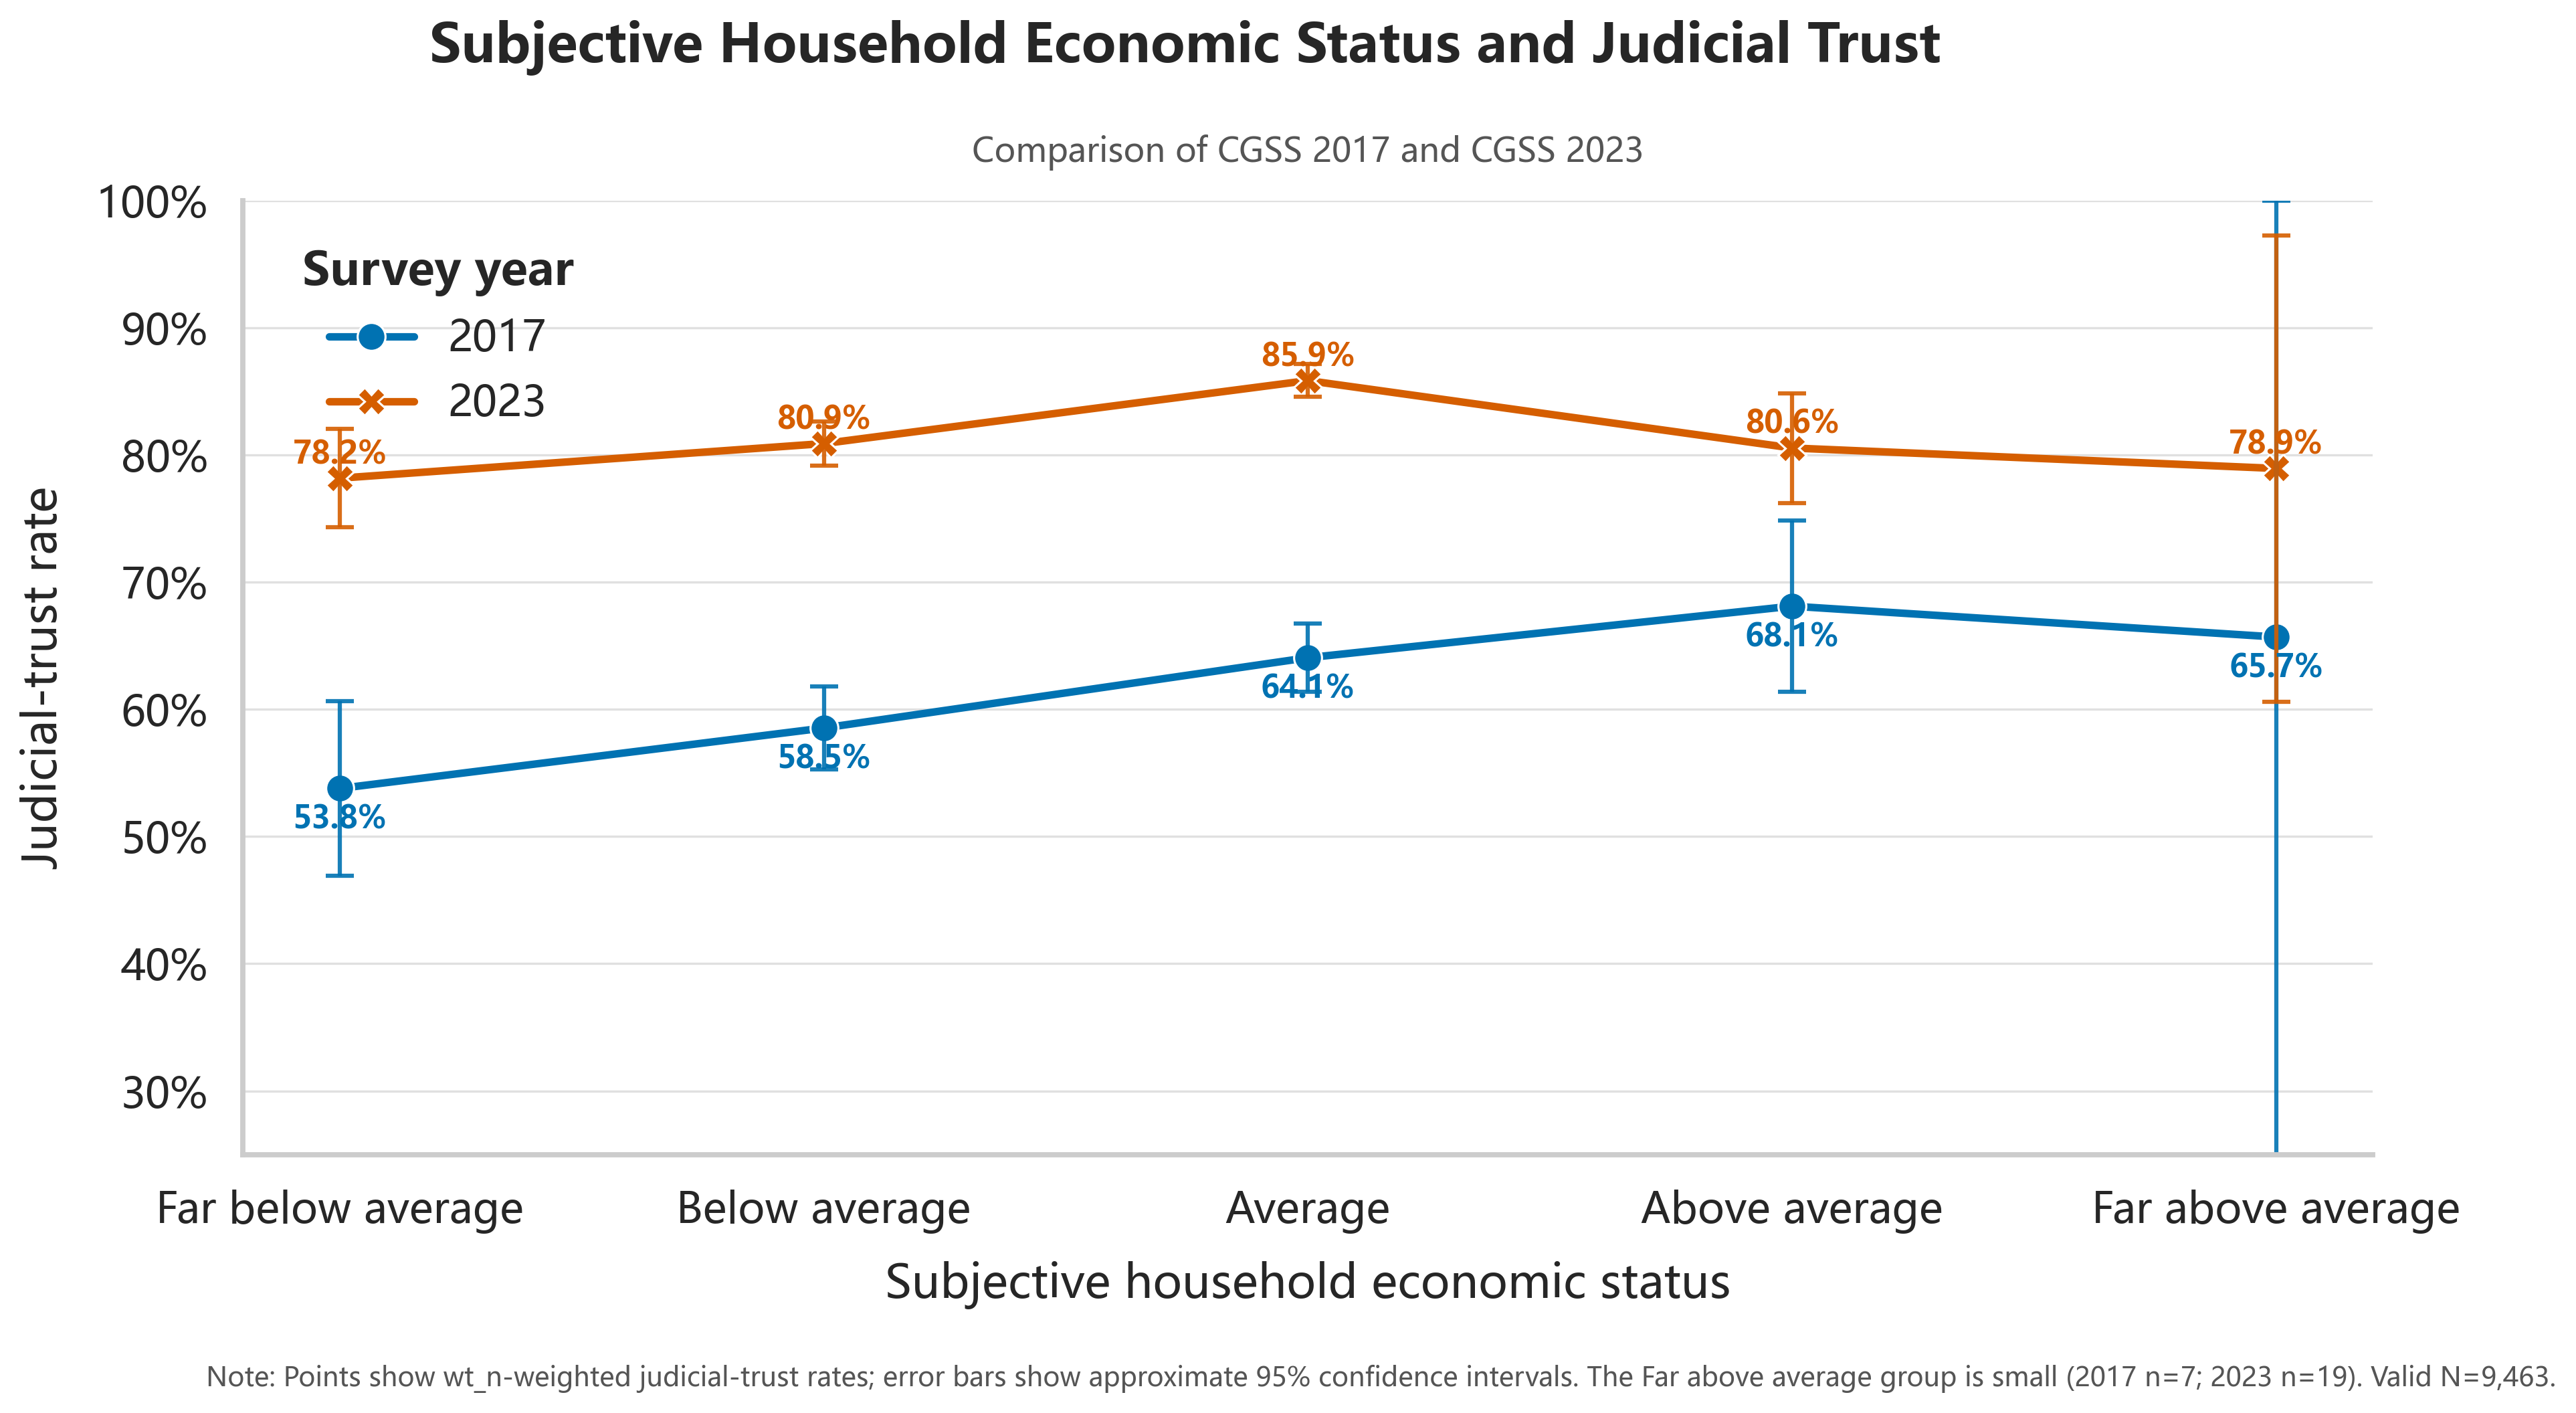

In [5]:
econ_analysis = load_and_prepare(pooled_path)
econ_summary = weighted_summary(econ_analysis)
econ_table_path = NOTEBOOK_OUTPUT_DIR / "judicial_trust_by_econ_year.csv"
econ_figure_path = NOTEBOOK_FIGURE_DIR / "judicial_trust_by_econ_year.png"
econ_summary.to_csv(econ_table_path, index=False, encoding="utf-8-sig")
draw_figure(econ_summary, econ_figure_path, sample_size=len(econ_analysis))

print(econ_summary.to_string(index=False))
display(Image(filename=str(econ_figure_path)))


## 4. Birth cohort and judicial trust

This figure uses unadjusted, unweighted sample proportions and Wilson 95% confidence intervals.


In [6]:
COHORT_LABELS = {
    1: "Born in 1949 or earlier",
    2: "1950s",
    3: "1960s",
    4: "1970s",
    5: "1980s",
    6: "1990 or later",
}
YEAR_COLORS = {2017: "#0072B2", 2023: "#D55E00"}


def configure_chinese_font() -> None:
    installed = {font.name for font in font_manager.fontManager.ttflist}
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]
    selected = next((name for name in candidates if name in installed), "DejaVu Sans")
    plt.rcParams["font.sans-serif"] = [selected, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


def calculate_raw_rates(input_path: Path) -> pd.DataFrame:
    data = pd.read_csv(input_path)
    required = {"year", "cohort", "trust_bin"}
    missing_columns = required.difference(data.columns)
    if missing_columns:
        raise ValueError(f"The input data is missing required variables: {sorted(missing_columns)}")

    analysis = data.dropna(subset=list(required)).copy()
    analysis = analysis.loc[
        analysis["year"].isin([2017, 2023])
        & analysis["cohort"].isin(COHORT_LABELS)
        & analysis["trust_bin"].isin([0, 1])
    ].copy()
    analysis["year"] = analysis["year"].astype(int)
    analysis["cohort"] = analysis["cohort"].astype(int)

    records: list[dict[str, float | int | str]] = []
    z_value = 1.96
    for (year, cohort), group in analysis.groupby(["year", "cohort"], sort=True):
        sample_size = len(group)
        successes = int(group["trust_bin"].sum())
        trust_rate = successes / sample_size

        # Wilson interval for an unweighted binomial proportion.
        denominator = 1 + z_value**2 / sample_size
        center = (trust_rate + z_value**2 / (2 * sample_size)) / denominator
        half_width = (
            z_value
            * np.sqrt(
                trust_rate * (1 - trust_rate) / sample_size
                + z_value**2 / (4 * sample_size**2)
            )
            / denominator
        )
        records.append(
            {
                "year": int(year),
                "cohort": int(cohort),
                "cohort_label": COHORT_LABELS[int(cohort)],
                "n": sample_size,
                "trust_count": successes,
                "trust_rate": trust_rate,
                "ci_low": max(0.0, center - half_width),
                "ci_high": min(1.0, center + half_width),
            }
        )

    summary = pd.DataFrame.from_records(records)
    baseline = summary.loc[summary["year"].eq(2017), ["cohort", "trust_rate"]]
    baseline = baseline.rename(columns={"trust_rate": "trust_rate_2017"})
    summary = summary.merge(baseline, on="cohort", how="left")
    summary["change_pp"] = (summary["trust_rate"] - summary["trust_rate_2017"]) * 100
    summary.loc[summary["year"].eq(2017), "change_pp"] = 0.0
    return summary


def draw_raw_plot(summary: pd.DataFrame, output_path: Path) -> None:
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.90)
    configure_chinese_font()

    figure, axis = plt.subplots(figsize=(11.6, 7.3))
    cohort_order = list(COHORT_LABELS.values())

    sns.lineplot(
        data=summary,
        x="cohort_label",
        y="trust_rate",
        hue="year",
        style="year",
        markers=True,
        dashes=False,
        palette=YEAR_COLORS,
        linewidth=2.7,
        markersize=10,
        sort=False,
        ax=axis,
    )

    x_positions = np.arange(len(cohort_order))
    for year in (2017, 2023):
        year_data = (
            summary.loc[summary["year"].eq(year)]
            .set_index("cohort_label")
            .reindex(cohort_order)
        )
        rates = year_data["trust_rate"].to_numpy(dtype=float)
        lower_error = rates - year_data["ci_low"].to_numpy(dtype=float)
        upper_error = year_data["ci_high"].to_numpy(dtype=float) - rates
        axis.errorbar(
            x_positions,
            rates,
            yerr=np.vstack([lower_error, upper_error]),
            fmt="none",
            ecolor=YEAR_COLORS[year],
            elinewidth=1.45,
            capsize=4.5,
            capthick=1.4,
            alpha=0.9,
            zorder=2,
        )

    cohort_80 = summary.loc[summary["cohort"].eq(5)].set_index("year")
    change_80 = (cohort_80.loc[2023, "trust_rate"] - cohort_80.loc[2017, "trust_rate"]) * 100
    axis.annotate(
        f"Largest raw increase: 1980s cohort\n+{change_80:.1f} percentage points",
        xy=(4, cohort_80.loc[2023, "trust_rate"]),
        xytext=(3.22, 0.91),
        fontsize=10.5,
        color="#8C3B00",
        ha="center",
        va="center",
        arrowprops={"arrowstyle": "->", "color": "#D55E00", "lw": 1.5},
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "#FFF2E8",
            "edgecolor": "#D55E00",
            "alpha": 0.95,
        },
    )

    axis.set_ylim(0.50, 0.95)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    axis.set_xlabel("Birth cohort", labelpad=12)
    axis.set_ylabel("Raw judicial-trust rate", labelpad=12)
    axis.grid(axis="x", visible=False)
    axis.grid(axis="y", color="#D9D9D9", linewidth=0.8, alpha=0.85)
    sns.despine(ax=axis, left=False, bottom=False)

    legend = axis.legend(
        title="Survey year", frameon=False, loc="upper left", bbox_to_anchor=(0.01, 0.99)
    )
    legend.get_title().set_fontweight("semibold")

    total_n = int(summary["n"].sum())
    figure.suptitle(
        "Birth Cohort and Judicial Trust: Raw Rates",
        fontsize=19,
        fontweight="bold",
        y=0.965,
    )
    axis.set_title(
        "Unadjusted sample proportions in CGSS 2017 and CGSS 2023",
        fontsize=12,
        color="#555555",
        pad=14,
    )
    figure.subplots_adjust(left=0.105, right=0.985, bottom=0.20, top=0.84)
    figure.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(figure)


 year  cohort            cohort_label    n  trust_count  trust_rate   ci_low  ci_high  trust_rate_2017  change_pp
 2017       1 Born in 1949 or earlier  692          477    0.689306 0.653860 0.722662         0.689306   0.000000
 2017       2                   1950s  774          490    0.633075 0.598540 0.666295         0.633075   0.000000
 2017       3                   1960s  795          486    0.611321 0.576978 0.644593         0.611321   0.000000
 2017       4                   1970s  673          411    0.610698 0.573331 0.646810         0.610698   0.000000
 2017       5                   1980s  597          331    0.554439 0.514347 0.593835         0.554439   0.000000
 2017       6           1990 or later  422          279    0.661137 0.614704 0.704663         0.661137   0.000000
 2023       1 Born in 1949 or earlier  667          540    0.809595 0.778058 0.837586         0.689306  12.028884
 2023       2                   1950s 1222          960    0.785597 0.761710 0.807695   

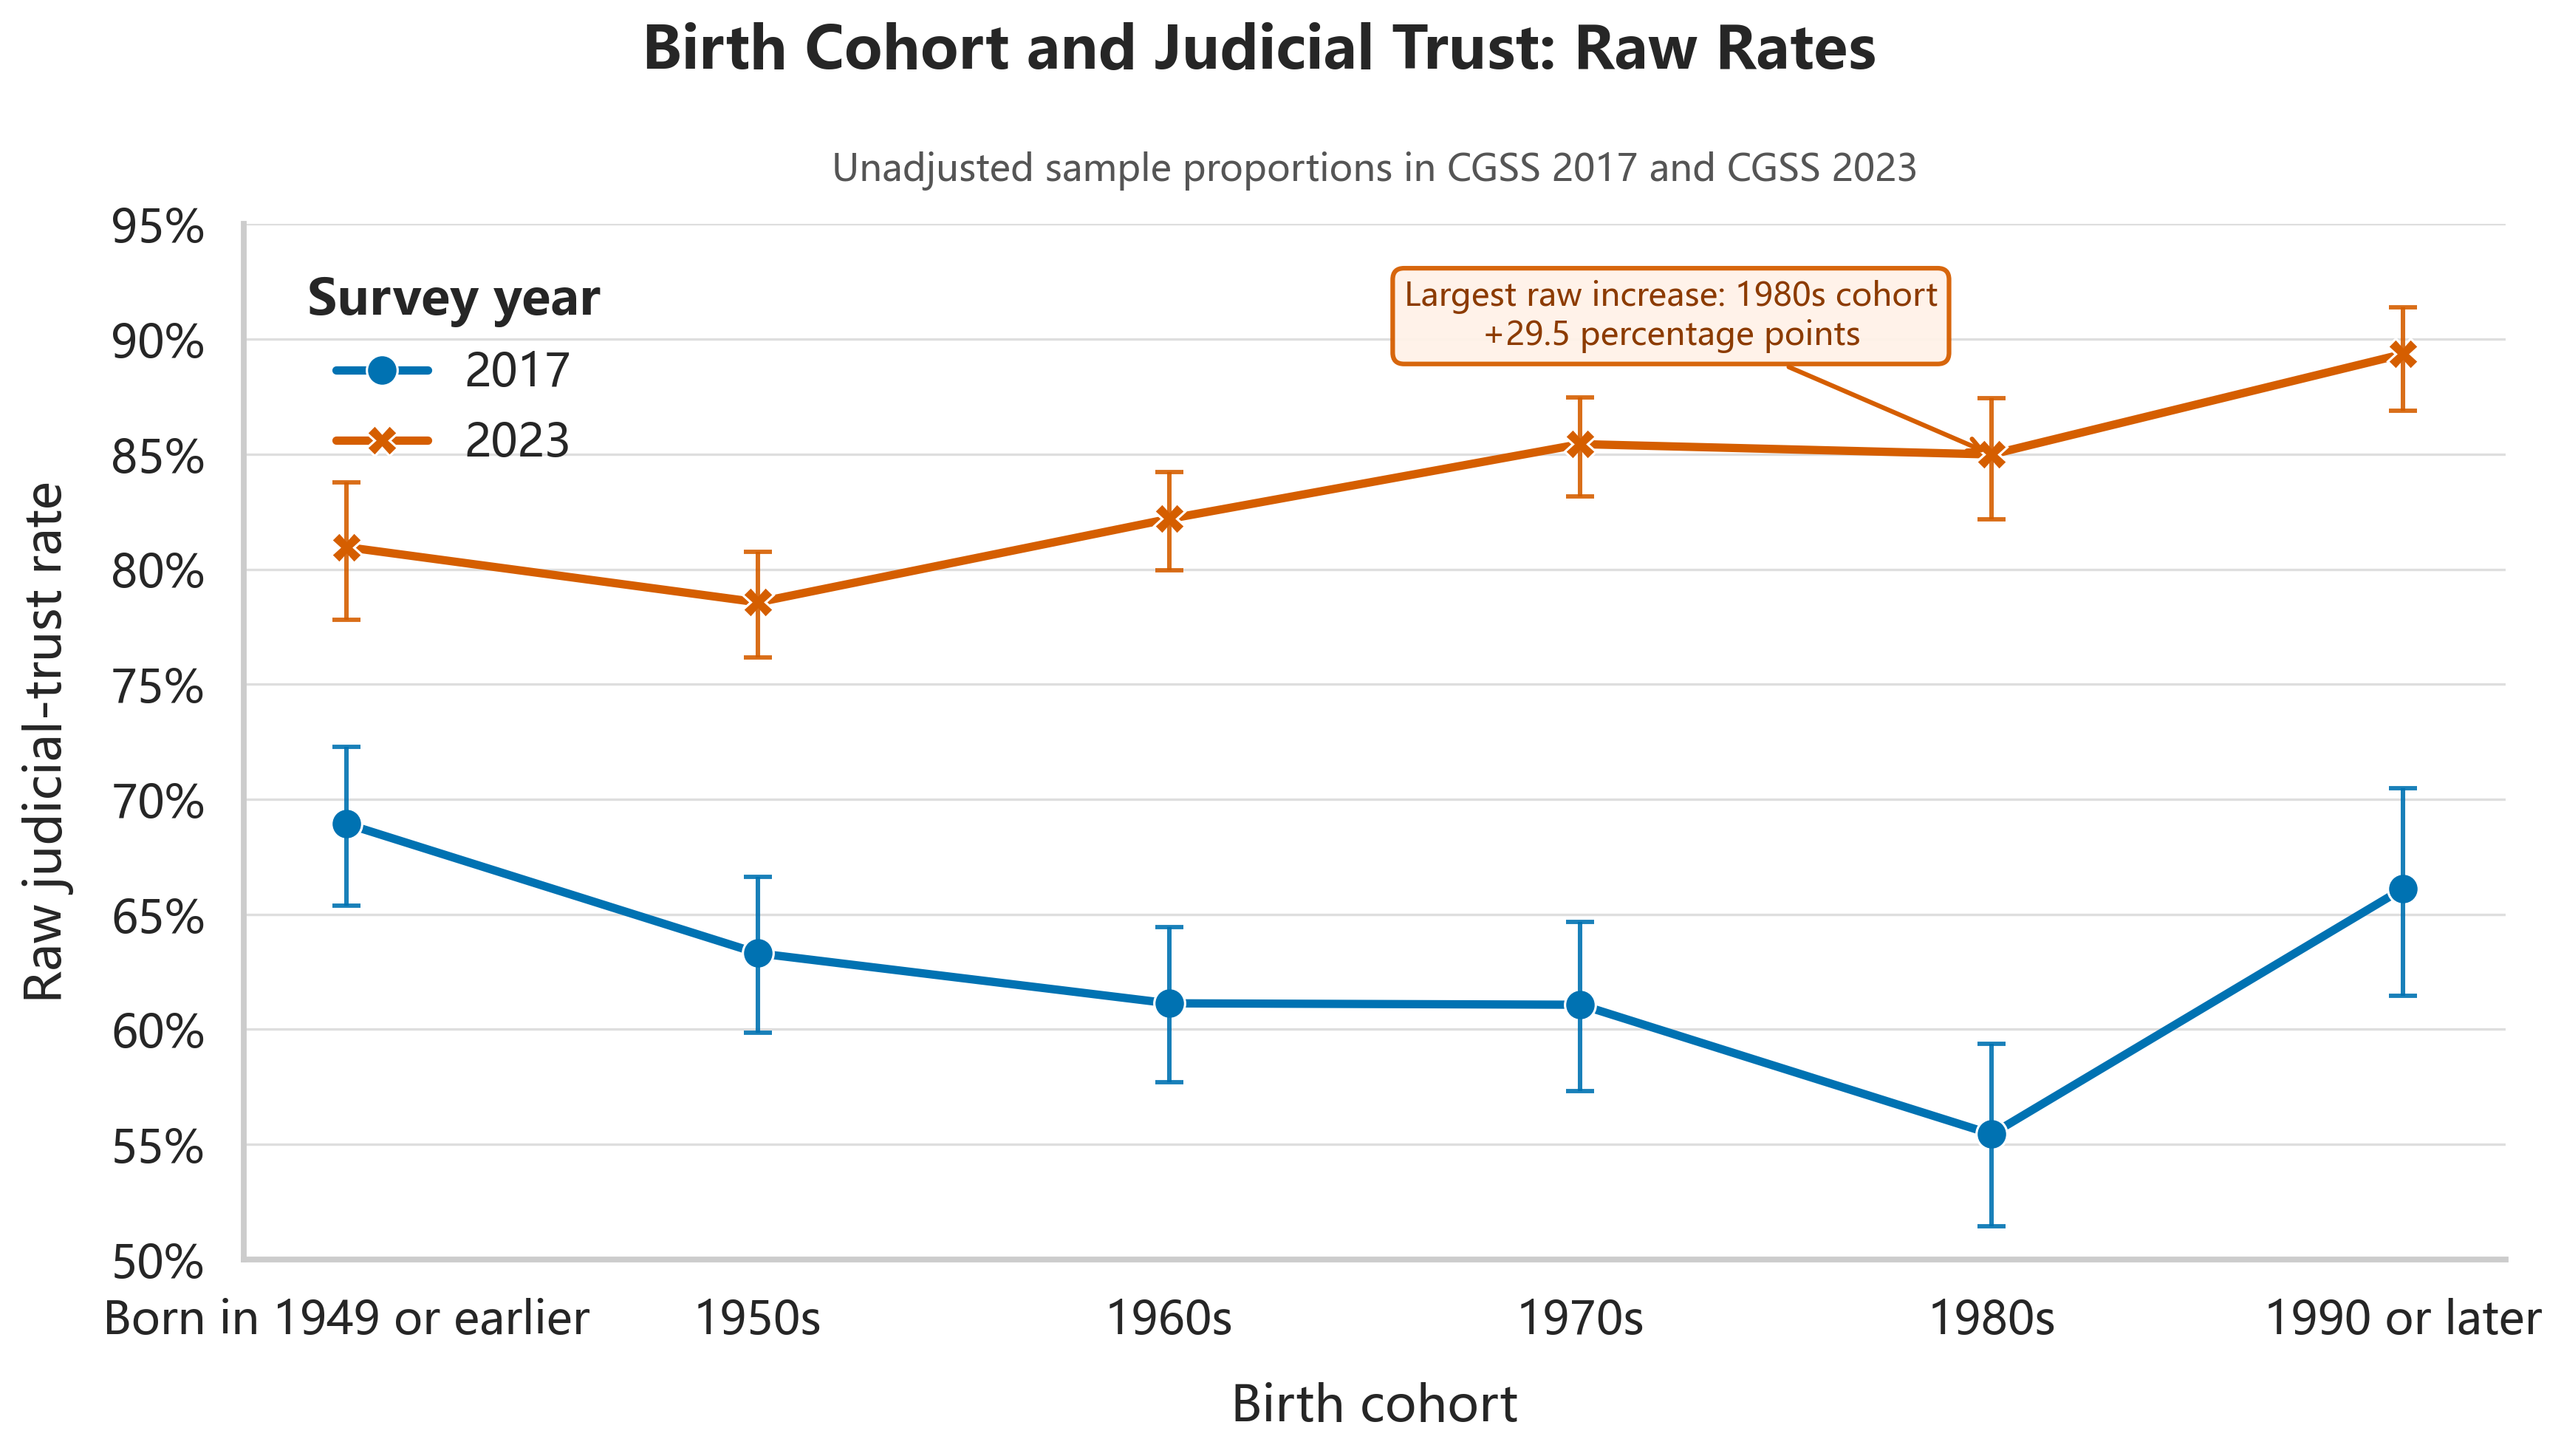

In [7]:
cohort_summary = calculate_raw_rates(pooled_path)
cohort_table_path = NOTEBOOK_OUTPUT_DIR / "judicial_trust_cohort_raw_rates.csv"
cohort_figure_path = NOTEBOOK_FIGURE_DIR / "judicial_trust_cohort_raw.png"
cohort_summary.to_csv(cohort_table_path, index=False, encoding="utf-8-sig")
draw_raw_plot(cohort_summary, cohort_figure_path)

print(cohort_summary.to_string(index=False))
display(Image(filename=str(cohort_figure_path)))


## 5. Province-level judicial-trust scatter plot

The scatter plot compares raw judicial-trust rates for provinces observed in both survey years. The x-axis shows 2017 and the y-axis shows 2023. Points above the 45-degree line have a higher trust rate in 2023.


In [8]:
PROVINCE_NAMES = {
    1: "Shanghai",
    2: "Yunnan",
    3: "Inner Mongolia",
    4: "Beijing",
    5: "Jilin",
    6: "Sichuan",
    7: "Tianjin",
    8: "Ningxia",
    9: "Anhui",
    10: "Shandong",
    11: "Shanxi",
    12: "Guangdong",
    13: "Guangxi",
    14: "Xinjiang",
    15: "Jiangsu",
    16: "Jiangxi",
    17: "Hebei",
    18: "Henan",
    19: "Zhejiang",
    20: "Hainan",
    21: "Hubei",
    22: "Hunan",
    23: "Gansu",
    24: "Fujian",
    25: "Tibet",
    26: "Guizhou",
    27: "Liaoning",
    28: "Chongqing",
    29: "Shaanxi",
    30: "Qinghai",
    31: "Heilongjiang",
}
REGION_NAMES = {1: "East", 2: "Central", 3: "West", 4: "Northeast"}
REGION_COLORS = {
    "East": "#0072B2",
    "Central": "#D55E00",
    "West": "#009E73",
    "Northeast": "#CC79A7",
}

# Offsets are in display points and keep nearby province labels readable.
LABEL_OFFSETS = {
    "Shanghai": (8, -12),
    "Yunnan": (-24, 9),
    "Jilin": (-28, -13),
    "Sichuan": (9, -12),
    "Tianjin": (-28, -13),
    "Anhui": (8, -13),
    "Shanxi": (9, 7),
    "Guangxi": (9, 8),
    "Jiangxi": (-30, 8),
    "Hebei": (-28, -13),
    "Henan": (9, 8),
    "Gansu": (9, -13),
    "Fujian": (9, -13),
    "Liaoning": (9, -13),
    "Chongqing": (9, 8),
    "Qinghai": (9, 8),
}


def configure_chinese_font() -> None:
    installed = {font.name for font in font_manager.fontManager.ttflist}
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]
    selected = next((name for name in candidates if name in installed), "DejaVu Sans")
    plt.rcParams["font.sans-serif"] = [selected, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


def calculate_province_rates(input_path: Path) -> tuple[pd.DataFrame, dict[int, int]]:
    data = pd.read_csv(input_path)
    required = {"year", "s41", "region", "trust_bin"}
    missing_columns = required.difference(data.columns)
    if missing_columns:
        raise ValueError(f"The input data is missing required variables: {sorted(missing_columns)}")

    analysis = data.dropna(subset=list(required)).copy()
    analysis = analysis.loc[
        analysis["year"].isin([2017, 2023])
        & analysis["s41"].isin(PROVINCE_NAMES)
        & analysis["region"].isin(REGION_NAMES)
        & analysis["trust_bin"].isin([0, 1])
    ].copy()
    analysis[["year", "s41", "region"]] = analysis[["year", "s41", "region"]].astype(int)

    coverage = analysis.groupby("year")["s41"].nunique().astype(int).to_dict()
    grouped = (
        analysis.groupby(["s41", "year"], as_index=False)
        .agg(n=("trust_bin", "size"), trust_rate=("trust_bin", "mean"))
    )
    rates = grouped.pivot(index="s41", columns="year", values=["n", "trust_rate"])
    rates = rates.dropna().copy()
    rates.columns = [f"{measure}_{int(year)}" for measure, year in rates.columns]
    rates = rates.reset_index()

    province_regions = analysis.groupby("s41")["region"].first().astype(int)
    rates["s41"] = rates["s41"].astype(int)
    rates["province"] = rates["s41"].map(PROVINCE_NAMES)
    rates["region_code"] = rates["s41"].map(province_regions)
    rates["region"] = rates["region_code"].map(REGION_NAMES)
    rates["n_2017"] = rates["n_2017"].astype(int)
    rates["n_2023"] = rates["n_2023"].astype(int)
    rates["change_pp"] = (rates["trust_rate_2023"] - rates["trust_rate_2017"]) * 100
    return rates.sort_values("s41").reset_index(drop=True), coverage


def draw_scatter(
    rates: pd.DataFrame,
    coverage: dict[int, int],
    output_path: Path,
) -> None:
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.90)
    configure_chinese_font()

    figure, axis = plt.subplots(figsize=(9.6, 9.1))
    sns.scatterplot(
        data=rates,
        x="trust_rate_2017",
        y="trust_rate_2023",
        hue="region",
        hue_order=list(REGION_COLORS),
        palette=REGION_COLORS,
        s=125,
        edgecolor="white",
        linewidth=1.2,
        alpha=0.95,
        ax=axis,
        zorder=3,
    )

    lower_limit, upper_limit = 0.40, 0.95
    axis.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        linestyle="--",
        color="#777777",
        linewidth=1.4,
        label="45-degree reference line",
        zorder=1,
    )

    for row in rates.itertuples(index=False):
        offset = LABEL_OFFSETS.get(row.province, (8, 6))
        axis.annotate(
            row.province,
            xy=(row.trust_rate_2017, row.trust_rate_2023),
            xytext=offset,
            textcoords="offset points",
            ha="left" if offset[0] >= 0 else "right",
            va="center",
            fontsize=9.5,
            color="#2F2F2F",
            bbox={
                "boxstyle": "round,pad=0.12",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.72,
            },
            zorder=4,
        )

    axis.text(
        0.425,
        0.515,
        "Above the line: higher trust in 2023",
        fontsize=10.5,
        color="#555555",
        rotation=45,
        ha="left",
        va="bottom",
    )
    axis.set_xlim(lower_limit, upper_limit)
    axis.set_ylim(lower_limit, upper_limit)
    axis.set_aspect("equal", adjustable="box")
    axis.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    axis.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    axis.set_xlabel("Raw judicial-trust rate in 2017", labelpad=12)
    axis.set_ylabel("Raw judicial-trust rate in 2023", labelpad=12)
    axis.grid(color="#D9D9D9", linewidth=0.8, alpha=0.8)
    sns.despine(ax=axis, left=False, bottom=False)

    handles, labels = axis.get_legend_handles_labels()
    axis.legend(
        handles,
        labels,
        title="Region",
        frameon=False,
        loc="lower right",
        borderaxespad=0.8,
    )

    figure.suptitle(
        "Province-level Judicial Trust: 2017 vs. 2023",
        fontsize=19,
        fontweight="bold",
        y=0.975,
    )
    axis.set_title(
        f"{len(rates)} province-level units observed in both years",
        fontsize=12,
        color="#555555",
        pad=14,
    )

    figure.subplots_adjust(left=0.13, right=0.96, bottom=0.10, top=0.88)
    figure.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(figure)


 s41  n_2017  n_2023  trust_rate_2017  trust_rate_2023  province  region_code    region  change_pp
   1     294     503         0.656463         0.799205  Shanghai            1      East  14.274219
   2     137     460         0.671533         0.908696    Yunnan            3      West  23.716281
   5     159     252         0.578616         0.757937     Jilin            4 Northeast  17.932016
   6     176     500         0.664773         0.826000   Sichuan            3      West  16.122727
   7     156     200         0.596154         0.680000   Tianjin            1      East   8.384615
   9     135     401         0.600000         0.825436     Anhui            2   Central  22.543641
  11      81     335         0.456790         0.877612    Shanxi            2   Central  42.082182
  13     120     401         0.616667         0.857855   Guangxi            3      West  24.118869
  16     142     404         0.584507         0.849010   Jiangxi            2   Central  26.450286
  17      

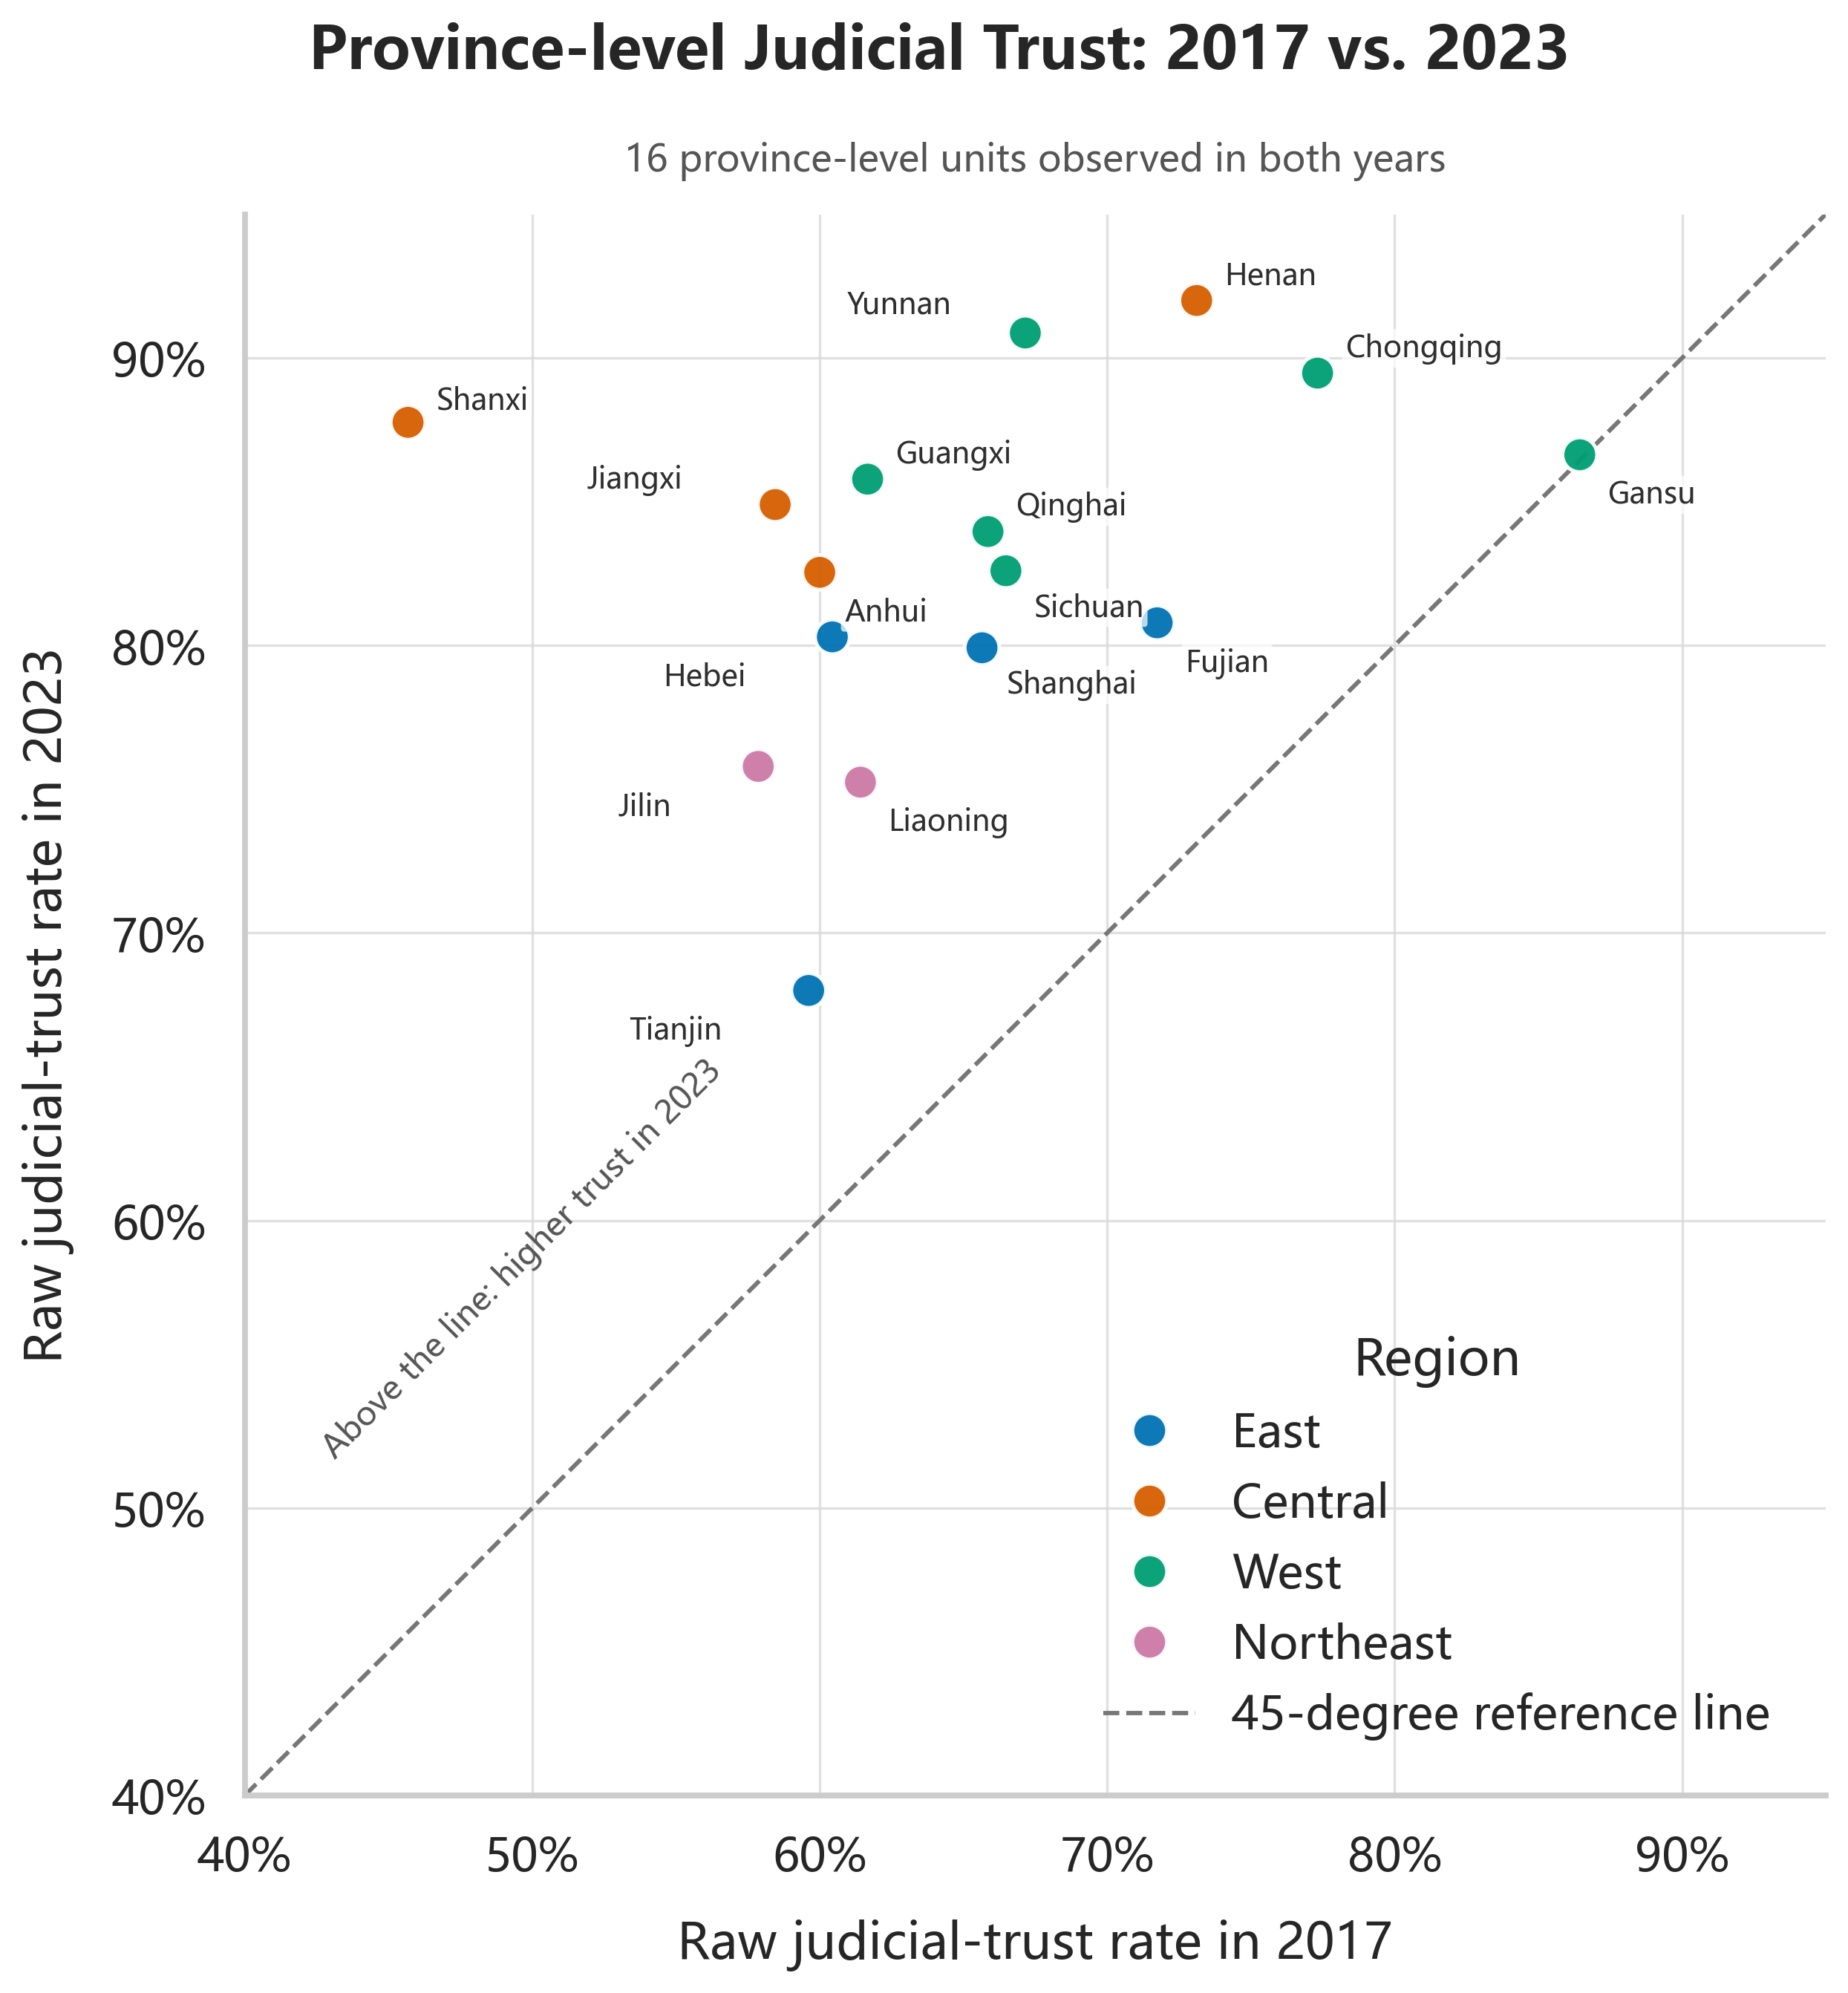

In [9]:
province_rates, province_coverage = calculate_province_rates(pooled_path)
province_table_path = NOTEBOOK_OUTPUT_DIR / "regional_judicial_trust_rates.csv"
province_figure_path = NOTEBOOK_FIGURE_DIR / "regional_judicial_trust_scatter.png"
province_rates.to_csv(province_table_path, index=False, encoding="utf-8-sig")
draw_scatter(province_rates, province_coverage, province_figure_path)

print(province_rates.to_string(index=False))
display(Image(filename=str(province_figure_path)))


## 6. Internet-use frequency and adjusted judicial trust

M2 is a weighted linear probability model with binary judicial trust as the dependent variable. It controls for survey year, birth cohort, gender, education, hukou status, Party membership, region, subjective household economic status, income group, social insurance, and employment status. Standard errors are clustered by area.


In [10]:
INTERNET_LABELS = {
    1: "Never",
    2: "Rarely",
    3: "Sometimes",
    4: "Often",
    5: "Very frequently",
}
CONTINUOUS = ["female", "edu_years", "party", "econ_subj", "si_any", "internet"]
CATEGORICAL = ["year", "cohort", "hukou", "region", "incq", "empstat"]


def configure_chinese_font() -> None:
    """Choose an installed Chinese font while retaining portable fallbacks."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]
    selected = next((name for name in candidates if name in installed), "DejaVu Sans")
    plt.rcParams["font.sans-serif"] = [selected, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


def prepare_m2_sample(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """Create the complete-case M2 design matrix and aligned model inputs."""
    required = ["trust_bin", "wt_n", "s42c", *CONTINUOUS, *CATEGORICAL]
    missing = set(required).difference(data.columns)
    if missing:
        raise ValueError(f"The input data is missing required variables: {sorted(missing)}")

    sample = data.dropna(subset=required).copy()
    sample = sample.loc[
        sample["trust_bin"].isin([0, 1])
        & sample["internet"].between(1, 5)
        & sample["wt_n"].gt(0)
    ].copy()

    numeric = sample[CONTINUOUS].astype(float)
    categorical = pd.get_dummies(
        sample[CATEGORICAL].astype(int).astype(str),
        prefix=CATEGORICAL,
        drop_first=True,
        dtype=float,
    )
    design = pd.concat([numeric, categorical], axis=1)
    design.insert(0, "constant", 1.0)
    return (
        design,
        sample["trust_bin"].astype(float),
        sample["wt_n"].astype(float),
        sample["s42c"].astype(str),
    )


def fit_m2(
    design: pd.DataFrame,
    outcome: pd.Series,
    weights: pd.Series,
    clusters: pd.Series,
) -> tuple[np.ndarray, np.ndarray, int]:
    """Fit weighted LPM M2 with finite-sample-corrected cluster covariance."""
    x = design.to_numpy(dtype=float)
    y = outcome.to_numpy(dtype=float)
    w = weights.to_numpy(dtype=float)

    bread = np.linalg.pinv(x.T @ (w[:, None] * x))
    beta = bread @ (x.T @ (w * y))
    residual = y - x @ beta
    scores = x * (w * residual)[:, None]

    cluster_codes, unique_clusters = pd.factorize(clusters, sort=False)
    cluster_scores = np.zeros((len(unique_clusters), x.shape[1]), dtype=float)
    np.add.at(cluster_scores, cluster_codes, scores)
    meat = cluster_scores.T @ cluster_scores

    n_observations, n_parameters = x.shape
    n_clusters = len(unique_clusters)
    correction = (n_clusters / (n_clusters - 1)) * (
        (n_observations - 1) / (n_observations - n_parameters)
    )
    covariance = correction * bread @ meat @ bread
    return beta, covariance, n_clusters


def adjusted_predictions(
    design: pd.DataFrame,
    weights: pd.Series,
    beta: np.ndarray,
    covariance: np.ndarray,
    n_clusters: int,
) -> pd.DataFrame:
    """Average M2 predictions after setting everyone to each internet-use level."""
    critical_value = float(student_t.ppf(0.975, n_clusters - 1))
    rows: list[dict[str, float | int | str]] = []
    for level, label in INTERNET_LABELS.items():
        scenario = design.copy()
        scenario["internet"] = float(level)
        average_design = np.average(
            scenario.to_numpy(dtype=float),
            axis=0,
            weights=weights.to_numpy(dtype=float),
        )
        prediction = float(average_design @ beta)
        standard_error = float(np.sqrt(max(average_design @ covariance @ average_design, 0.0)))
        rows.append(
            {
                "internet_level": level,
                "internet_label": label,
                "adjusted_probability": prediction,
                "standard_error": standard_error,
                "ci_low": prediction - critical_value * standard_error,
                "ci_high": prediction + critical_value * standard_error,
            }
        )
    return pd.DataFrame(rows)


def draw_figure(predictions: pd.DataFrame, output_path: Path) -> None:
    """Create the adjusted-probability line chart."""
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.92)
    configure_chinese_font()

    x = predictions["internet_level"].to_numpy(dtype=float)
    y = predictions["adjusted_probability"].to_numpy(dtype=float)
    lower_error = y - predictions["ci_low"].to_numpy(dtype=float)
    upper_error = predictions["ci_high"].to_numpy(dtype=float) - y

    figure, axis = plt.subplots(figsize=(11.4, 7.1))
    axis.plot(
        x,
        y,
        color="#0072B2",
        marker="o",
        markersize=10,
        linewidth=2.8,
        zorder=3,
    )
    axis.errorbar(
        x,
        y,
        yerr=np.vstack([lower_error, upper_error]),
        fmt="none",
        ecolor="#0072B2",
        elinewidth=1.7,
        capsize=5,
        capthick=1.7,
        alpha=0.9,
        zorder=2,
    )
    for x_value, probability in zip(x, y, strict=True):
        axis.text(
            x_value,
            probability + 0.006,
            f"{probability:.1%}",
            ha="center",
            va="bottom",
            fontsize=11,
            color="#005A8D",
            fontweight="semibold",
        )

    figure.suptitle(
        "Internet-use Frequency and Adjusted Judicial Trust",
        fontsize=20,
        fontweight="bold",
        y=0.965,
    )
    axis.set_title(
        "Predictions and 95% confidence intervals from the weighted M2 linear probability model",
        fontsize=12.5,
        color="#555555",
        pad=15,
    )
    axis.set_xticks(list(INTERNET_LABELS))
    axis.set_xticklabels(list(INTERNET_LABELS.values()))
    axis.set_xlabel("Internet-use frequency", labelpad=11)
    axis.set_ylabel("Adjusted probability of judicial trust", labelpad=11)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    padding = 0.025
    axis.set_ylim(
        max(0.0, float(predictions["ci_low"].min()) - padding),
        min(1.0, float(predictions["ci_high"].max()) + padding),
    )
    axis.grid(axis="x", visible=False)
    axis.grid(axis="y", color="#D9D9D9", linewidth=0.8, alpha=0.8)
    sns.despine(ax=axis, left=False, bottom=False)
    figure.subplots_adjust(left=0.13, right=0.98, bottom=0.15, top=0.83)
    figure.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(figure)


 internet_level  internet_label  adjusted_probability  standard_error   ci_low  ci_high    n  clusters
              1           Never              0.787191        0.015648 0.756073 0.818309 9235        85
              2          Rarely              0.768607        0.012125 0.744494 0.792719 9235        85
              3       Sometimes              0.750022        0.009326 0.731476 0.768567 9235        85
              4           Often              0.731437        0.008045 0.715439 0.747435 9235        85
              5 Very frequently              0.712852        0.008958 0.695038 0.730667 9235        85

Change in adjusted judicial-trust probability per one-category increase in internet use: -1.86%


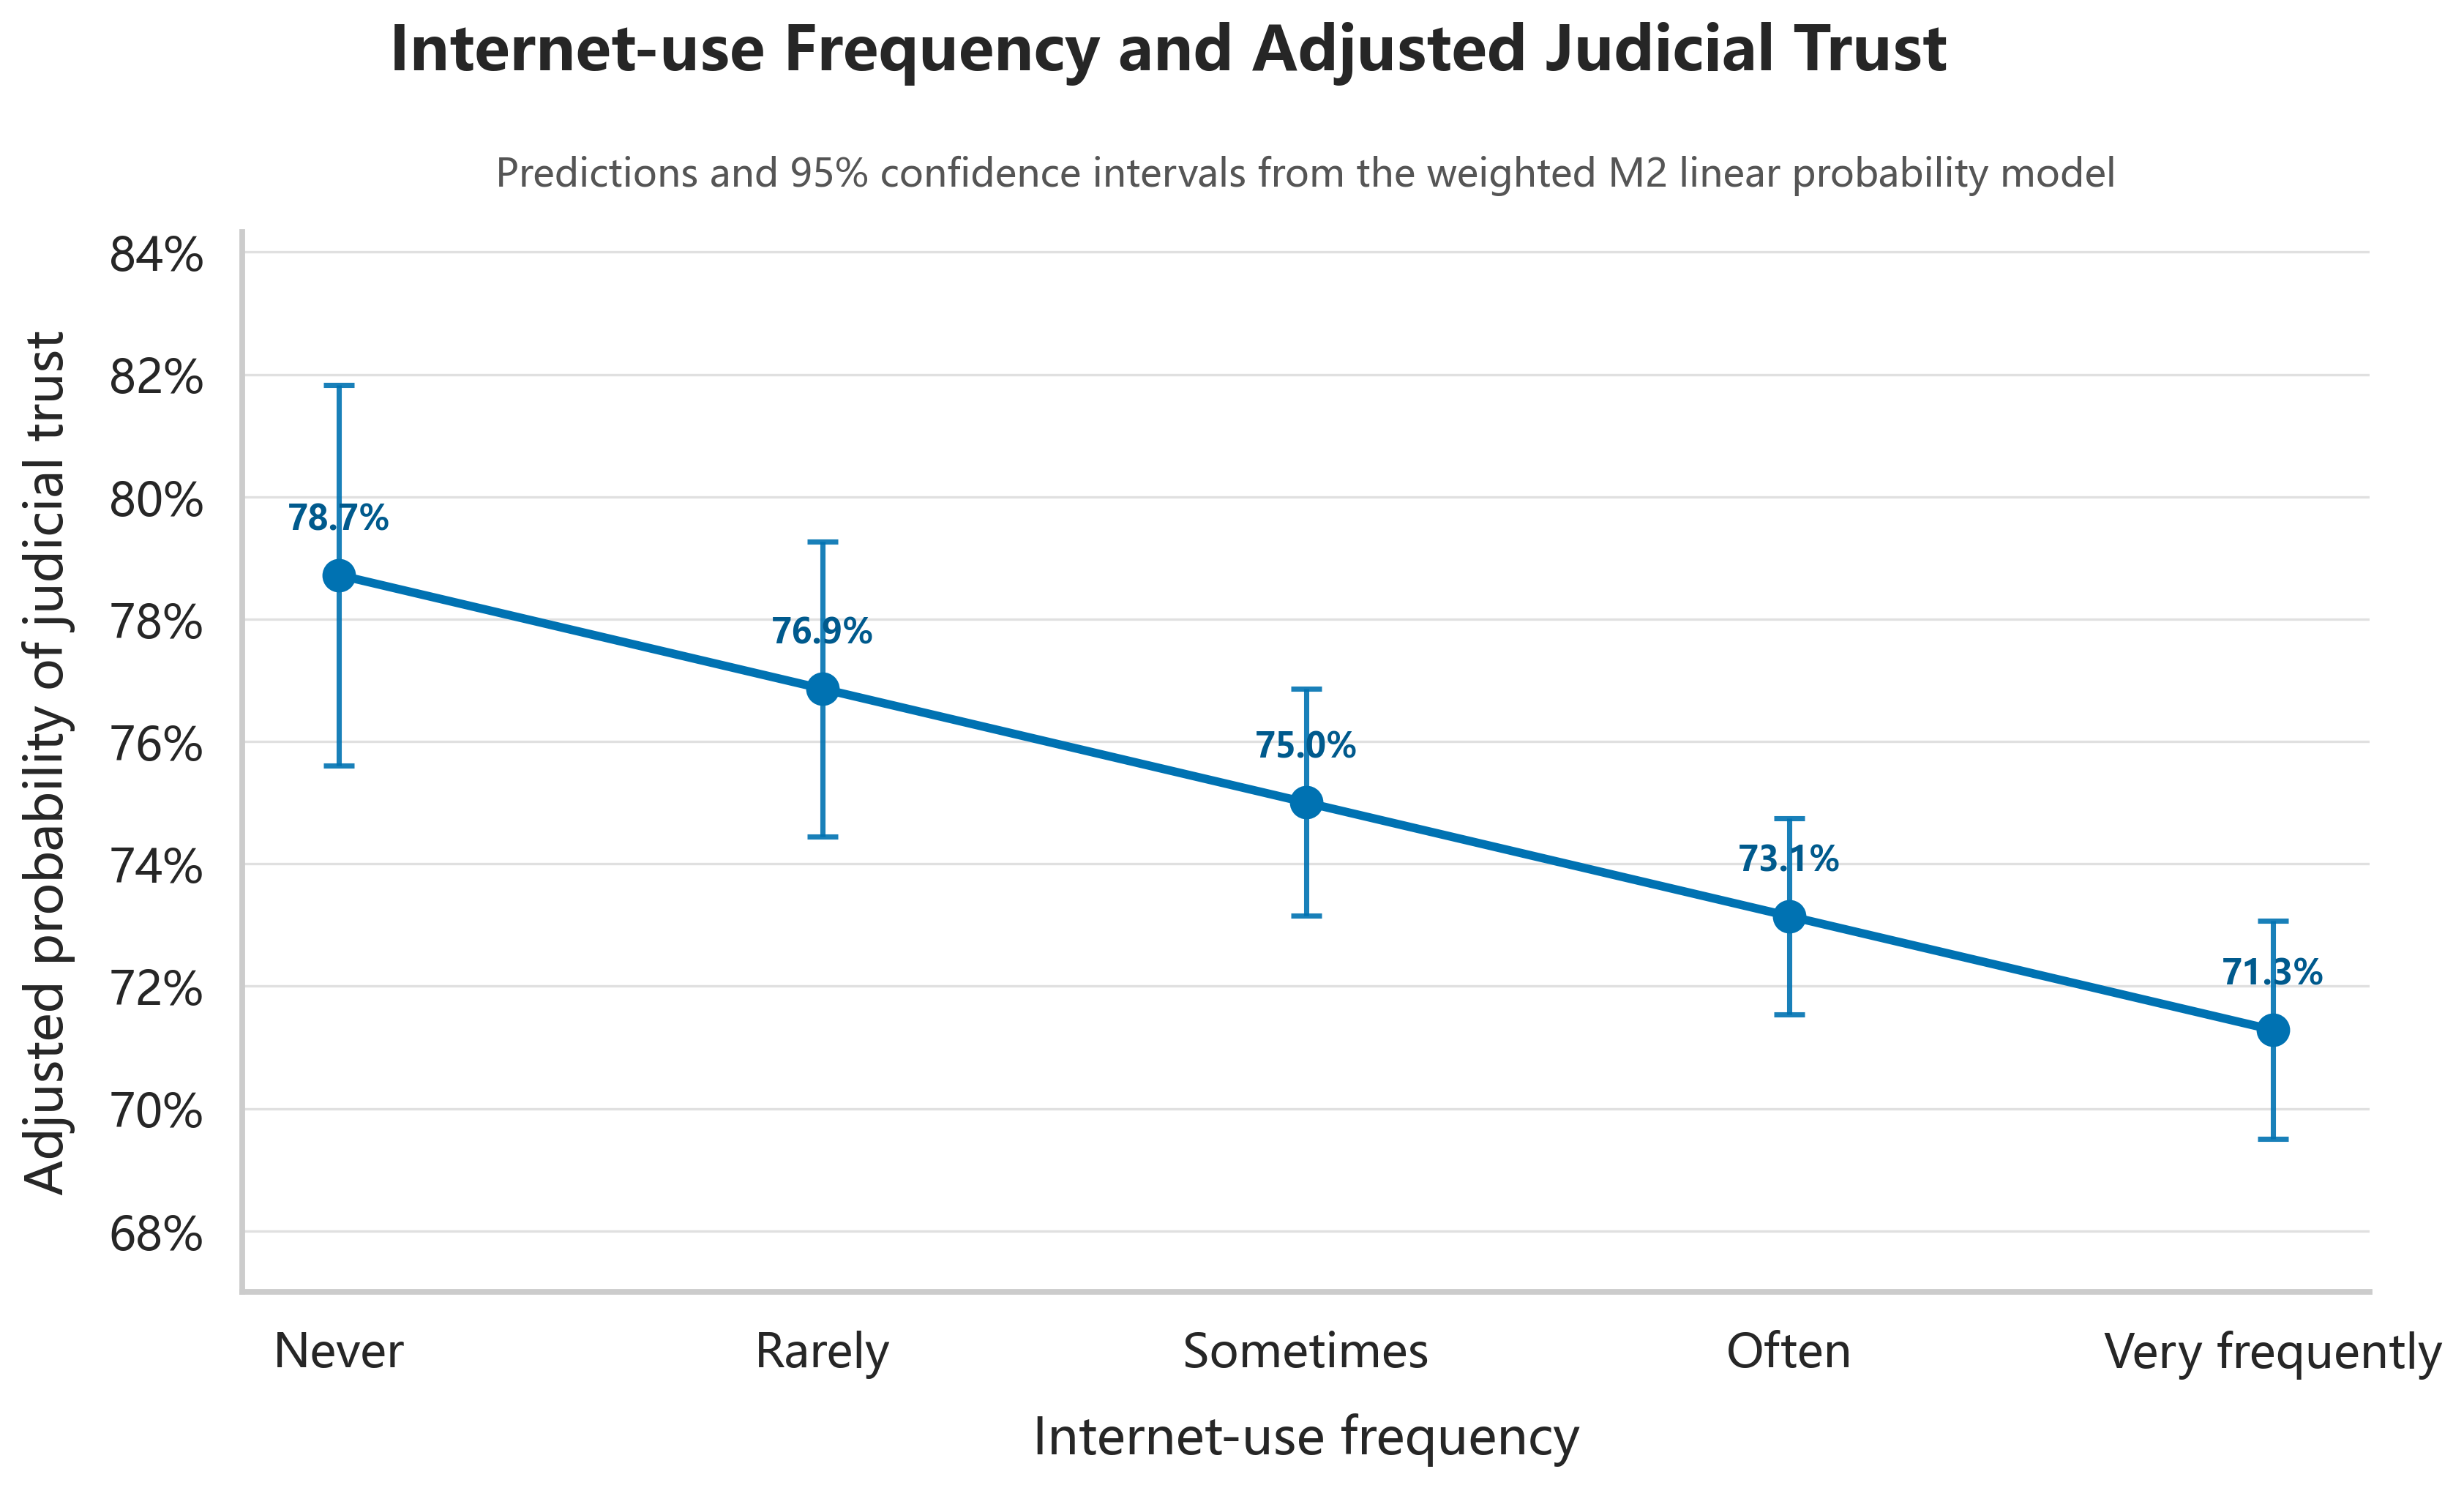

In [11]:
internet_data = pd.read_csv(pooled_path)
design, outcome, model_weights, clusters = prepare_m2_sample(internet_data)
beta, covariance, n_clusters = fit_m2(design, outcome, model_weights, clusters)
internet_predictions = adjusted_predictions(
    design, model_weights, beta, covariance, n_clusters
)
internet_predictions["n"] = len(outcome)
internet_predictions["clusters"] = n_clusters

internet_table_path = NOTEBOOK_OUTPUT_DIR / "internet_trust_m2_adjusted_predictions.csv"
internet_figure_path = NOTEBOOK_FIGURE_DIR / "internet_trust_m2_adjusted_predictions.png"
internet_predictions.to_csv(internet_table_path, index=False, encoding="utf-8-sig")
draw_figure(internet_predictions, internet_figure_path)

internet_coefficient = beta[design.columns.get_loc("internet")]
print(internet_predictions.to_string(index=False))
print(f"\nChange in adjusted judicial-trust probability per one-category increase in internet use: {internet_coefficient:.2%}")
display(Image(filename=str(internet_figure_path)))


## 7. Output files

After running all cells:

- the pooled dataset and chart summary tables are saved in `cgss_python/outputs/notebook/`;
- figures are saved in `code/figures/notebook/`; and
- the original `.py` scripts and production outputs remain unchanged.
